In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 1. LOAD DATA
# ==========================================================
df = pd.read_csv("C:/All GCM Data/Bias correctd/ALL_Raw_Correction.csv")

obs = df["IMD"].values


In [4]:
# Identify before- and after-bias model columns
before_cols = [c for c in df.columns if "raw" in c.lower()]
after_cols = [c for c in df.columns 
              if c not in before_cols and c not in ["Date", "IMD"]]

In [5]:
# 2. FUNCTION TO COMPUTE STATISTICS FOR EACH MODEL
# ==========================================================
def compute_stats(cols):
    stats = []
    for col in cols:
        s = df[col].values
        mask = np.isfinite(obs) & np.isfinite(s)
        o, sm = obs[mask], s[mask]

        std_s = np.std(sm, ddof=0)
        corr = np.corrcoef(o, sm)[0, 1] if np.std(sm) > 0 else 0.0
        crmse = np.sqrt(np.mean(((sm - sm.mean()) - (o - o.mean()))**2))

        stats.append({
            "name": col,
            "std": std_s,
            "corr": corr,
            "crmse": crmse
        })
    return stats

stats_before = compute_stats(before_cols)
stats_after = compute_stats(after_cols)

# Std. deviation of observed dataset
std_ref = np.std(obs, ddof=0)

In [6]:
# 3. helper for CRMSE contours
# ==========================================================
def draw_crmse_contours(ax, std_ref, maxstd, levels=None):
    # create theta,r grid
    thetas = np.linspace(0, np.pi/2, 300)
    rs = np.linspace(0, maxstd, 300)
    TT, RR = np.meshgrid(thetas, rs)
    CRMSE = np.sqrt(np.maximum(std_ref**2 + RR**2 - 2 * std_ref * RR * np.cos(TT), 0.0))
    if levels is None:
        levels = np.linspace(0, maxstd, 6)[1:]
    cs = ax.contour(TT, RR, CRMSE, levels=levels, linestyles=':', colors='k', linewidths=0.9)
    return cs

# ==========================================================
# 4. TAYLOR DIAGRAM PLOT FUNCTION
# ==========================================================
def plot_panel(ax, stats, title, numbering_prefix=""):
    maxstd = max([s["std"] for s in stats] + [std_ref]) * 1.25

    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)
    ax.set_thetamin(0)
    ax.set_thetamax(90)
    ax.set_ylim(0, maxstd)

    # ---- Correlation Coefficient Lines ----
    corrs = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,0.99]
    angles = np.arccos(corrs)
    for a in angles:
        ax.plot([a, a], [0, maxstd], linestyle=(0,(6,6)), color='blue', linewidth=1.0)

    for c, a in zip(corrs, angles):
        ax.text(a, maxstd * 1.02, f"{c:.2f}".rstrip('0').rstrip('.'), color='blue',
                fontsize=12, ha="center", va="bottom")

    # ---- Standard Deviation Circles (green dashed) ----
    radii = np.linspace(0, maxstd, 6)[1:]
    for r in radii:
        ax.plot(np.linspace(0, np.pi/2, 300), [r] * 300, linestyle=(0,(5,3)), color='green', linewidth=0.9)

    # ---- CRMSE dotted black contours ----
    crmse_levels = np.linspace(0, maxstd, 6)[1:]
    draw_crmse_contours(ax, std_ref, maxstd, levels=crmse_levels)

    # Outer heavy quarter-circle
    th = np.linspace(0, np.pi/2, 400)
    ax.plot(th, [maxstd]*len(th), color='black', linewidth=2)

    # Observed point
    ax.plot(0, std_ref, 'o', color='#7a0f0f', markersize=11, label='Observed')

    # Model points: pick colors from a palette
    palette = ['#ff7f0e','#2ca02c','#98df8a','#1f77b4','#8c564b','#9467bd','#d62728','#17becf']
    for i, s in enumerate(stats):
        theta = np.arccos(np.clip(s['corr'], -1, 1))
        color = palette[i % len(palette)]
        ax.plot(theta, s['std'], 'o', color=color, markersize=9)
        # add numeric label (1,2,3,4 or 1-c etc.) next to point
        #label_num = f"{i+1}{numbering_prefix}"
        #ax.text(theta, s['std'] * 1.06, label_num, fontsize=12, fontweight='bold',
               # horizontalalignment='center', verticalalignment='bottom')

    # radial ticks and labels
    rticks = np.linspace(0, maxstd, 5)
    ax.set_yticks(rticks)
    ax.set_yticklabels([f"{r:.0f}" for r in rticks], fontsize=11)
    ax.set_xticklabels([])

    # legend: observed + model short names
    handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#7a0f0f', markersize=8)]
    labels = ['Observed']
    for i, s in enumerate(stats):
        handles.append(plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=palette[i%len(palette)], markersize=8))
        short = s['name'].replace('_before_bias','').replace('_before-bias','').replace('_beofre_bias','')
        labels.append(short)
    ax.legend(handles, labels, fontsize=9, loc='upper right', bbox_to_anchor=(1.32, 1.05), frameon=True)

    ax.set_title(title, fontsize=16, fontweight='bold')


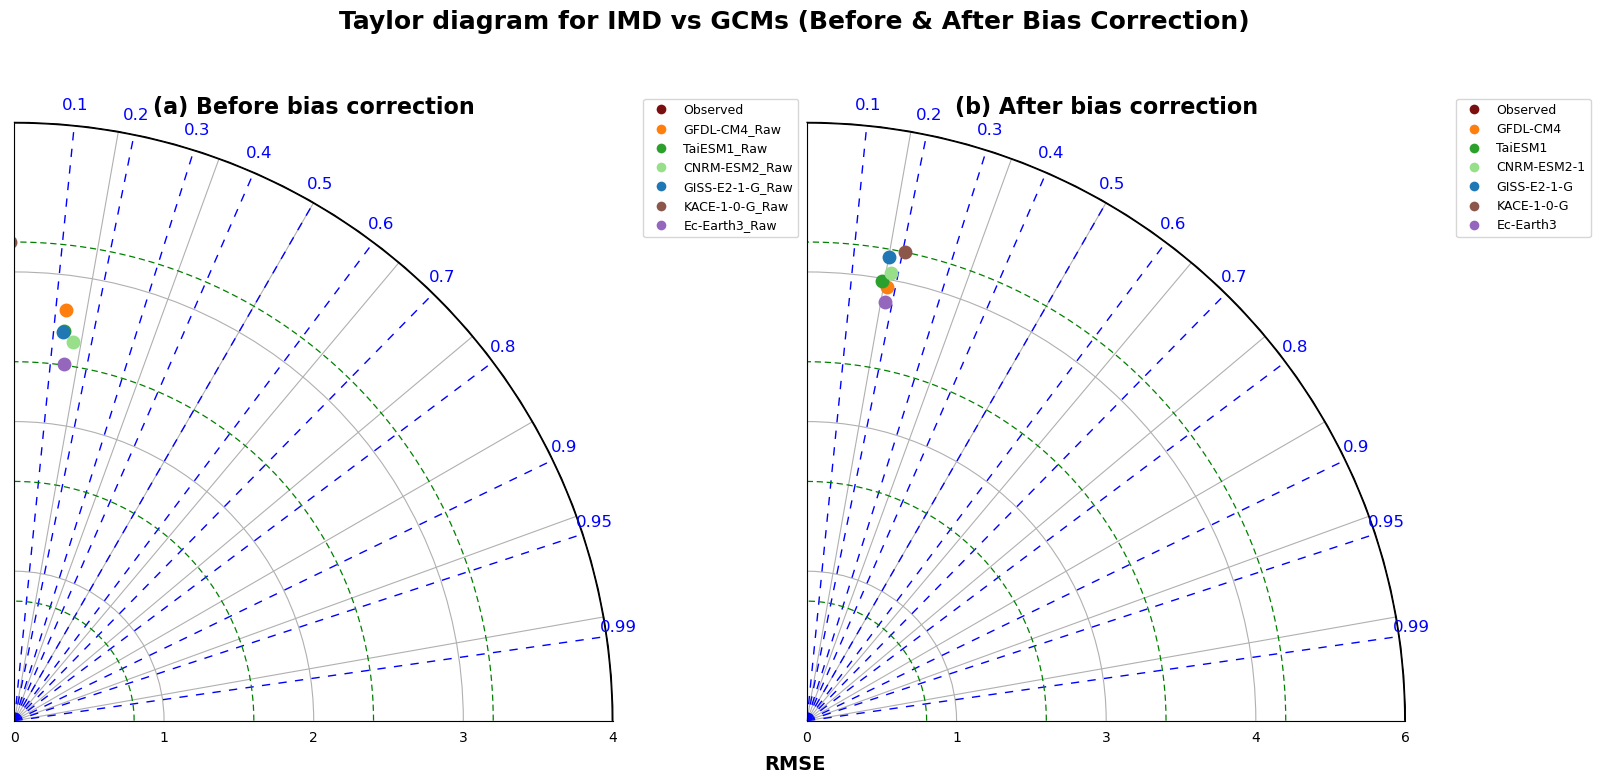

In [7]:
# 5. FINAL FIGURE WITH TWO PANELS
# ==========================================================
fig = plt.figure(figsize=(16,8))

ax1 = plt.subplot(121, projection='polar')
ax2 = plt.subplot(122, projection='polar')

plot_panel(ax1, stats_before, "(a) Before bias correction", numbering_prefix="")
plot_panel(ax2, stats_after, "(b) After bias correction", numbering_prefix="-c")

fig.suptitle("Taylor diagram for IMD vs GCMs (Before & After Bias Correction)", fontsize=18, y=0.98, fontweight='bold')

# add RMSE label below (approximate position)
plt.figtext(0.5, 0.03, "RMSE", ha='center', fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0,0.03,1,0.95])

# Save high-res
#plt.savefig("C:/Users/Windows/Desktop/Taylor_two_panel_matched.png", dpi=600, bbox_inches='tight')
#print("Saved: Taylor_two_panel_matched.png")

plt.show()

Detected BEFORE columns: ['ACESS-CM5_before_bias', 'CanESM5_before_bias', 'CESM2-WACCM_before_bias', 'EC-EARTH3_before-bias', 'GFDL-CM4_before_bias', 'IIT-ESM_before-bias', 'BCC-CSM2_before-bias']
Detected AFTER columns:  ['ACESS-CM5', 'CanESM5', 'CESM2-WACCM', 'EC-EARTH3', 'GFDL-CM4', 'IIT-ESM', 'BCC-CSM2']

=== BEFORE - monthly stats ===
idx name                                   corr  theta_deg      std    crmse
  1 ACESS-CM5_before_bias                 0.974       13.1    1.839     1.53
  2 CanESM5_before_bias                   0.885       27.7    0.918    2.488
  3 CESM2-WACCM_before_bias               0.958       16.6    1.893    1.548
  4 EC-EARTH3_before-bias                 0.976       12.7    1.515    1.816
  5 GFDL-CM4_before_bias                  0.978       12.0    1.566    1.763
  6 IIT-ESM_before-bias                   0.974       13.0    1.681     1.67
  7 BCC-CSM2_before-bias                  0.929       21.7    1.558    1.906

=== AFTER  - monthly stats ===
idx name  

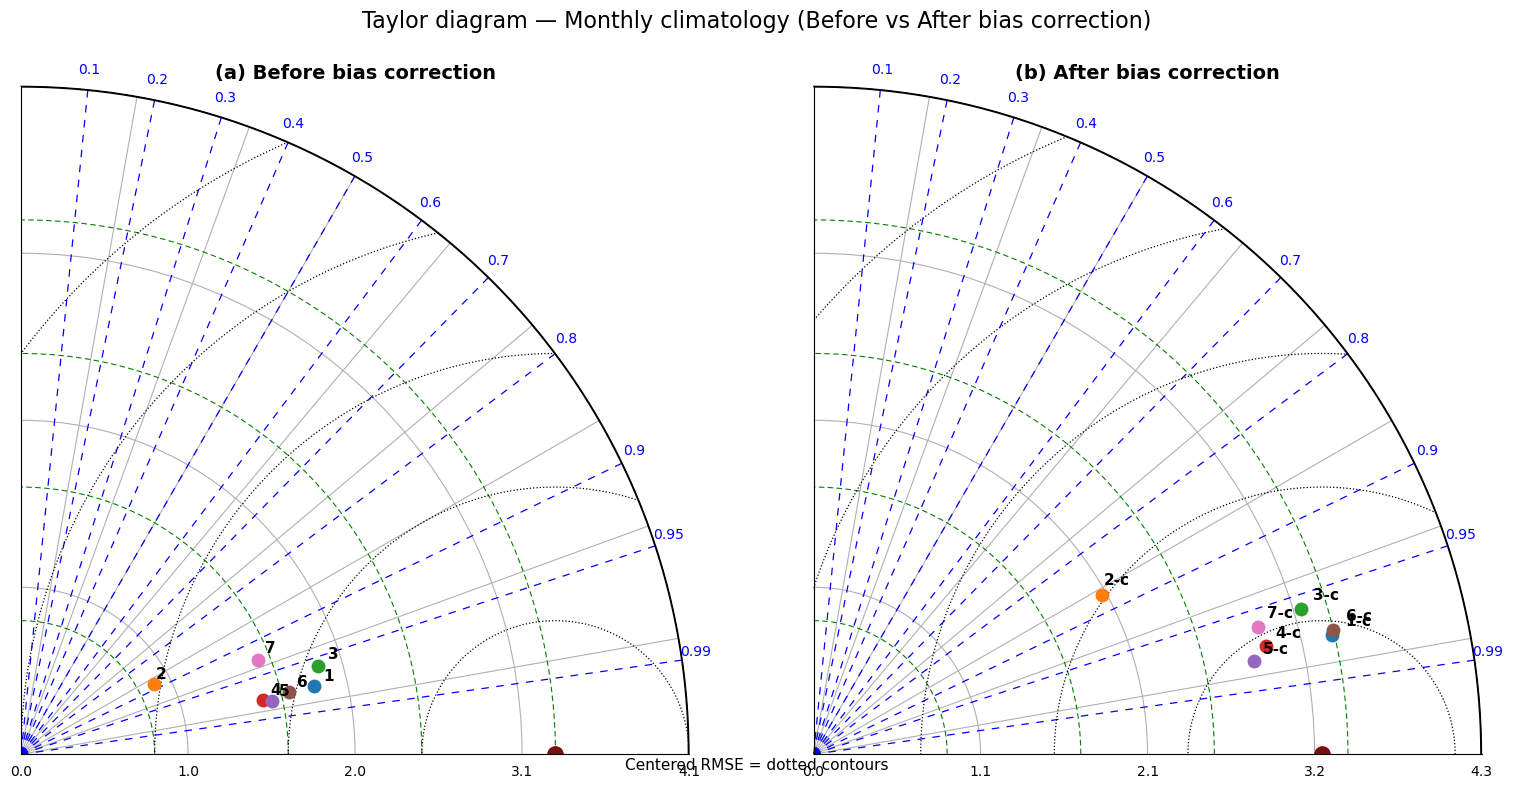

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------- CONFIG -----------------
CSV_FILE = "C:/Users/Windows/Desktop/ALL MODELs combined QM.csv"
OUT_PNG  = "Taylor_multi_model_monthly.png"
SAVE_DPI = 600
NUMBER_MODELS = True   # show 1,2,3 and 1-c,2-c,... next to points
# ------------------------------------------

# 1) LOAD & PREPARE MONTHLY CLIMATOLOGY (12 months)
df = pd.read_csv(CSV_FILE)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
if df['Date'].isna().all():
    raise ValueError("No valid dates parsed. Check CSV Date column format.")

# drop rows without Date or Obs
df = df.dropna(subset=['Date', 'IMD-Observerd']).copy()
df['month'] = df['Date'].dt.month

# compute monthly climatology (mean across years for each month)
monthly = df.groupby('month').mean().reindex(range(1,13)).reset_index()  # ensures months 1..12 order

# observed monthly climatology (length 12)
obs_monthly = monthly['IMD-Observerd'].values
std_ref = np.std(obs_monthly, ddof=0)

# 2) detect model columns
before_cols = [c for c in monthly.columns if 'before' in c.lower()]
exclude = set(['Date','IMD-Observerd','month','Year','Month'])
after_cols = [c for c in monthly.columns if c not in before_cols and c not in exclude]

if len(after_cols) == 0:
    raise ValueError("No after-bias model columns detected. Check your CSV column names.")

print("Detected BEFORE columns:", before_cols)
print("Detected AFTER columns: ", after_cols)
print()

# 3) compute statistics on monthly climatologies (corr, std, crmse)
def compute_stats_from_monthly(cols, monthly_df, obs):
    stats = []
    for col in cols:
        model_series = monthly_df[col].values
        # if any NaNs, handle by masking
        mask = np.isfinite(obs) & np.isfinite(model_series)
        o, m = obs[mask], model_series[mask]
        if len(o) < 2:
            corr = np.nan; std = np.nan; crmse = np.nan
        else:
            corr = np.corrcoef(o, m)[0,1] if np.std(m) > 0 else np.nan
            std = np.std(m, ddof=0)
            crmse = np.sqrt(np.mean(((m - m.mean()) - (o - o.mean()))**2))
        stats.append({'name': col, 'corr': corr, 'std': std, 'crmse': crmse})
    return stats

stats_before = compute_stats_from_monthly(before_cols, monthly, obs_monthly) if before_cols else []
stats_after  = compute_stats_from_monthly(after_cols, monthly, obs_monthly)

# print diagnostics
def print_stats_table(stats, title):
    print("=== {} ===".format(title))
    print(f"{'idx':>3} {'name':35s} {'corr':>7s} {'theta_deg':>10s} {'std':>8s} {'crmse':>8s}")
    for i,s in enumerate(stats, start=1):
        corr = s['corr']
        theta_deg = np.degrees(np.arccos(np.clip(corr, -1, 1))) if (not np.isnan(corr)) else np.nan
        print(f"{i:3d} {s['name'][:35]:35s} {np.round(corr,3):7} {np.round(theta_deg,1):10} {np.round(s['std'],3):8} {np.round(s['crmse'],3):8}")
    print()

if stats_before:
    print_stats_table(stats_before, "BEFORE - monthly stats")
print_stats_table(stats_after, "AFTER  - monthly stats")

# 4) helper to draw CRMSE contours on polar (TT,RR grid)
def draw_crmse_contours(ax, std_ref, maxstd, levels=None):
    thetas = np.linspace(0, np.pi/2, 400)
    rs = np.linspace(0, maxstd, 400)
    TT, RR = np.meshgrid(thetas, rs)
    CRMSE = np.sqrt(np.maximum(std_ref**2 + RR**2 - 2 * std_ref * RR * np.cos(TT), 0.0))
    if levels is None:
        levels = np.linspace(0, maxstd, 6)[1:]
    cs = ax.contour(TT, RR, CRMSE, levels=levels, linestyles=':', colors='k', linewidths=0.9)
    return cs

# 5) plotting function (two panels left=before, right=after)
def plot_panel(ax, stats, title, numbering_prefix=""):
    # radial limit
    maxstd = max([s['std'] for s in stats if not np.isnan(s['std'])] + [std_ref]) * 1.25

    # correct orientation
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)
    ax.set_thetamin(0); ax.set_thetamax(90)
    ax.set_ylim(0, maxstd)

    # correlation rays and labels
    corrs = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,0.99]
    for c in corrs:
        angle = np.arccos(c)
        ax.plot([angle, angle], [0, maxstd], linestyle=(0,(6,6)), color='blue', linewidth=0.9)
        ax.text(angle, maxstd*1.02, f"{c:.2f}".rstrip('0').rstrip('.'), color='blue', fontsize=10, ha='center', va='bottom')

    # SD rings (green dashed)
    radii = np.linspace(0, maxstd, 6)[1:]
    for r in radii:
        ax.plot(np.linspace(0,np.pi/2,400), [r]*400, linestyle=(0,(5,3)), color='green', linewidth=0.8)

    # CRMSE contours
    levels = np.linspace(0, maxstd, 6)[1:]
    draw_crmse_contours(ax, std_ref, maxstd, levels=levels)

    # heavy outer arc
    th = np.linspace(0, np.pi/2, 400)
    ax.plot(th, [maxstd]*len(th), color='black', linewidth=2)

    # observed point
    ax.plot(0, std_ref, 'o', color='#7a0f0f', markersize=11, label='Observed')

    # model points + numbering and short labels
    palette = plt.get_cmap('tab10')
    for i, s in enumerate(stats):
        corr, stdval = s['corr'], s['std']
        theta = np.arccos(np.clip(corr, -1, 1)) if not np.isnan(corr) else np.nan
        color = palette(i % 10)
        ax.plot(theta, stdval, 'o', color=color, markersize=9)
        # number label
        if NUMBER_MODELS:
            label_num = f"{i+1}{numbering_prefix}"
            ax.text(theta, stdval*1.05, label_num, fontsize=11, fontweight='bold', ha='center', va='bottom')
        # short name near point (optional, uncomment to show)
        # ax.text(theta, stdval*0.92, s['name'].replace('_','\n'), fontsize=7, ha='center', va='top')

    # radial ticks and title
    ax.set_yticks(np.linspace(0, maxstd, 5))
    ax.set_yticklabels([f"{r:.1f}" for r in np.linspace(0, maxstd, 5)], fontsize=9)
    ax.set_xticklabels([])
    ax.set_title(title, fontsize=14, fontweight='bold')
   
# 6) create figure
fig = plt.figure(figsize=(16,8))
ax1 = plt.subplot(121, projection='polar')
ax2 = plt.subplot(122, projection='polar')

if stats_before:
    plot_panel(ax1, stats_before, "(a) Before bias correction", numbering_prefix="")
else:
    # if no before models, draw a placeholder
    ax1.text(0.5,0.5,"No 'before' columns detected", ha='center', va='center', transform=ax1.transAxes)
    ax1.set_axis_off()

plot_panel(ax2, stats_after, "(b) After bias correction", numbering_prefix="-c")

fig.suptitle("Taylor diagram — Monthly climatology (Before vs After bias correction)", fontsize=16, y=0.98)

# caption / RMSE note
plt.figtext(0.5, 0.03, "Centered RMSE = dotted contours", ha='center', fontsize=11)

plt.tight_layout(rect=[0,0.03,1,0.95])
#plt.savefig(OUT_PNG, dpi=SAVE_DPI, bbox_inches='tight')
print("Saved:", OUT_PNG)
plt.show()


Detected BEFORE columns: ['GFDL-CM4_Raw', 'TaiESM1_Raw', 'CNRM-ESM2_Raw', 'GISS-E2-1-G_Raw', 'KACE-1-0-G_Raw', 'Ec-Earth3_Raw']
Detected AFTER columns:  ['GFDL-CM4', 'TaiESM1', 'CNRM-ESM2-1', 'GISS-E2-1-G', 'KACE-1-0-G', 'Ec-Earth3']

=== BEFORE - monthly stats ===
idx name                                   corr  theta_deg      std    crmse
  1 GFDL-CM4_Raw                          0.969       14.3    0.769     0.88
  2 TaiESM1_Raw                           0.945       19.1    0.825    0.868
  3 CNRM-ESM2_Raw                         0.975       12.9    0.837     0.81
  4 GISS-E2-1-G_Raw                       0.963       15.7    0.774    0.884
  5 KACE-1-0-G_Raw                        0.037       87.9    0.669    1.715
  6 Ec-Earth3_Raw                         0.991        7.8    0.736    0.881

=== AFTER  - monthly stats ===
idx name                                   corr  theta_deg      std    crmse
  1 GFDL-CM4                              0.977       12.3    1.596    0.342
  2 TaiES

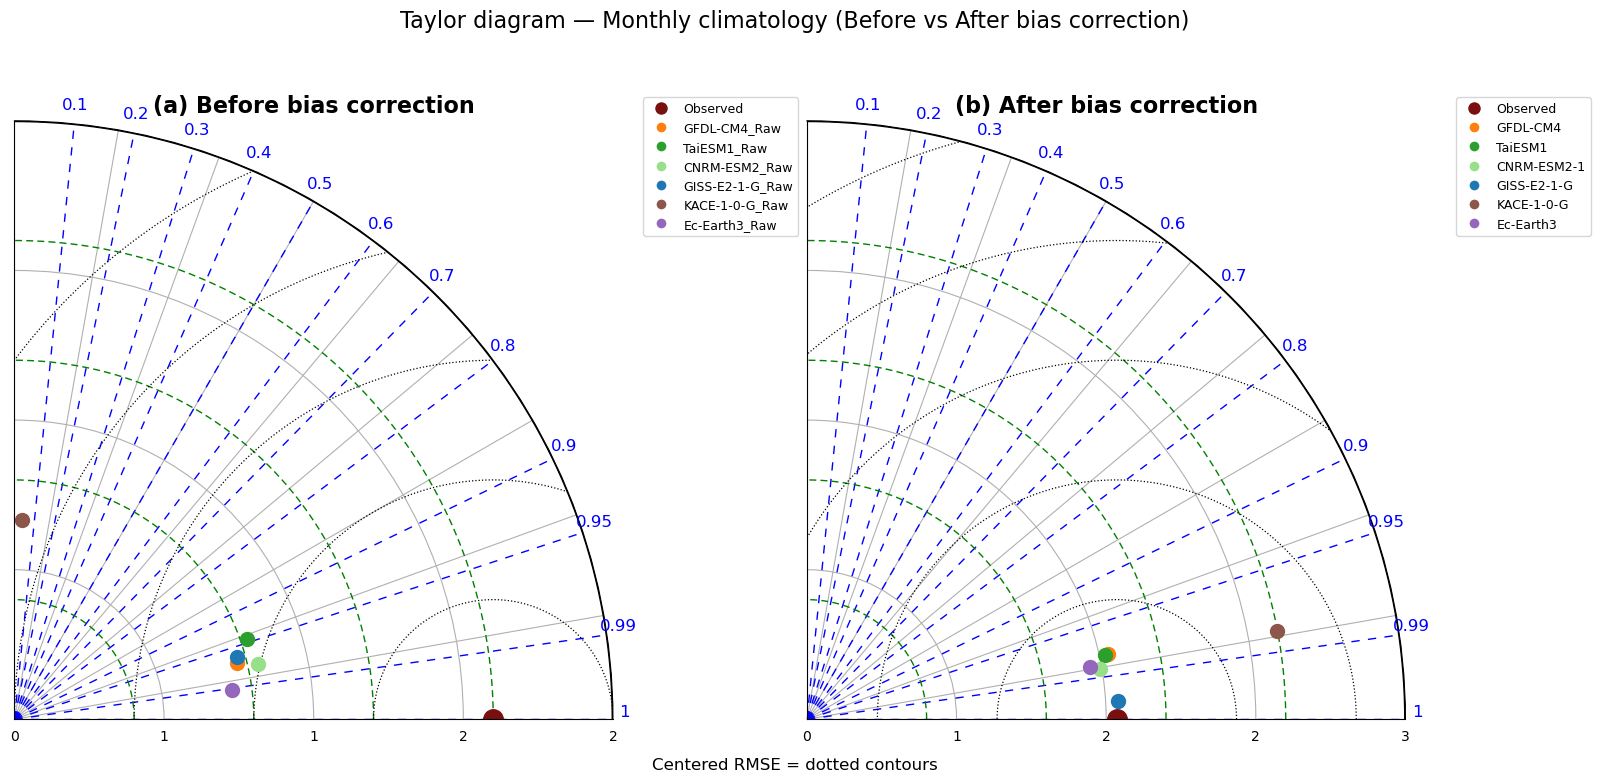

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------- CONFIG -----------------
CSV_FILE = "C:/All GCM Data/Bias correctd/ALL_Raw_Correction.csv"
OUT_PNG  = "C:/All GCM Data/Figures/Taylor_Before_After.png"
SAVE_DPI = 600
NUMBER_MODELS = True   # not used in this block, kept for compatibility
# ------------------------------------------

# ----------------- 1. LOAD & PREPARE MONTHLY CLIMATOLOGY -----------------
df = pd.read_csv(CSV_FILE)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
if df['Date'].isna().all():
    raise ValueError("No valid dates parsed. Check CSV Date column format.")

df = df.dropna(subset=['Date', 'IMD']).copy()
df['month'] = df['Date'].dt.month
monthly = df.groupby('month').mean().reindex(range(1,13)).reset_index()

# observed monthly climatology (length 12)
obs_monthly = monthly['IMD'].values
std_ref = np.std(obs_monthly, ddof=0)

# detect before/after columns
before_cols = [c for c in monthly.columns if 'raw' in c.lower()]
exclude = set(['Date','IMD','month','Year','Month'])
after_cols = [c for c in monthly.columns if c not in before_cols and c not in exclude]

print("Detected BEFORE columns:", before_cols)
print("Detected AFTER columns: ", after_cols)
print()

# ----------------- 2. compute stats for monthly climatology -----------------
def compute_stats_from_monthly(cols, monthly_df, obs):
    stats = []
    for col in cols:
        model_series = monthly_df[col].values
        mask = np.isfinite(obs) & np.isfinite(model_series)
        o, m = obs[mask], model_series[mask]
        if len(o) < 2:
            corr = np.nan; std = np.nan; crmse = np.nan
        else:
            corr = np.corrcoef(o, m)[0,1] if np.std(m) > 0 else np.nan
            std = np.std(m, ddof=0)
            crmse = np.sqrt(np.mean(((m - m.mean()) - (o - o.mean()))**2))
        stats.append({'name': col, 'corr': corr, 'std': std, 'crmse': crmse})
    return stats

stats_before = compute_stats_from_monthly(before_cols, monthly, obs_monthly) if before_cols else []
stats_after  = compute_stats_from_monthly(after_cols, monthly, obs_monthly)

# print simple tables
def print_stats_table(stats, title):
    print("=== {} ===".format(title))
    print(f"{'idx':>3} {'name':35s} {'corr':>7s} {'theta_deg':>10s} {'std':>8s} {'crmse':>8s}")
    for i,s in enumerate(stats, start=1):
        corr = s['corr']
        theta_deg = np.degrees(np.arccos(np.clip(corr, -1, 1))) if (not np.isnan(corr)) else np.nan
        print(f"{i:3d} {s['name'][:35]:35s} {np.round(corr,3):7} {np.round(theta_deg,1):10} {np.round(s['std'],3):8} {np.round(s['crmse'],3):8}")
    print()

if stats_before:
    print_stats_table(stats_before, "BEFORE - monthly stats")
print_stats_table(stats_after, "AFTER  - monthly stats")

# ----------------- 3. helper for CRMSE contours (your function) -----------------
def draw_crmse_contours(ax, std_ref, maxstd, levels=None):
    # create theta,r grid
    thetas = np.linspace(0, np.pi/2, 300)
    rs = np.linspace(0, maxstd, 300)
    TT, RR = np.meshgrid(thetas, rs)
    CRMSE = np.sqrt(np.maximum(std_ref**2 + RR**2 - 2 * std_ref * RR * np.cos(TT), 0.0))
    if levels is None:
        levels = np.linspace(0, maxstd, 6)[1:]
    cs = ax.contour(TT, RR, CRMSE, levels=levels, linestyles=':', colors='k', linewidths=0.9)
    return cs

# ----------------- 4. TAYLOR DIAGRAM PLOT FUNCTION (your code with tiny fixes) -----------------
def plot_panel(ax, stats, title, numbering_prefix=""):
    # use global std_ref
    maxstd = max([s["std"] for s in stats if not np.isnan(s["std"])] + [std_ref]) * 1.25

    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)
    ax.set_thetamin(0)
    ax.set_thetamax(90)
    ax.set_ylim(0, maxstd)

    # ---- Correlation Coefficient Lines ----
    corrs = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,0.99,1]
    angles = np.arccos(corrs)
    for a in angles:
        ax.plot([a, a], [0, maxstd], linestyle=(0,(6,6)), color='blue', linewidth=1.0)

    for c, a in zip(corrs, angles):
        ax.text(a, maxstd * 1.02, f"{c:.2f}".rstrip('0').rstrip('.'), color='blue',
                fontsize=12, ha="center", va="bottom")

    # ---- Standard Deviation Circles (green dashed) ----
    radii = np.linspace(0, maxstd, 6)[1:]
    for r in radii:
        ax.plot(np.linspace(0, np.pi/2, 300), [r] * 300, linestyle=(0,(5,3)), color='green', linewidth=1.0)

    # ---- CRMSE dotted black contours ----
    crmse_levels = np.linspace(0, maxstd, 6)[1:]
    draw_crmse_contours(ax, std_ref, maxstd, levels=crmse_levels)

    # Outer heavy quarter-circle
    th = np.linspace(0, np.pi/2, 400)
    ax.plot(th, [maxstd]*len(th), color='black', linewidth=2)

    # Observed point
    ax.plot(0, std_ref, 'o', color='#7a0f0f', markersize=14, label='IMD')

    # Model points: pick colors from a palette
    palette = ['#ff7f0e','#2ca02c','#98df8a','#1f77b4','#8c564b','#9467bd','#d62728','#17becf']
    for i, s in enumerate(stats):
        theta = np.arccos(np.clip(s['corr'], -1, 1)) if not np.isnan(s['corr']) else np.nan
        color = palette[i % len(palette)]
        ax.plot(theta, s['std'], 'o', color=color, markersize=10)
        # optionally add number labels:
        # label_num = f"{i+1}{numbering_prefix}"
        # ax.text(theta, s['std'] * 1.06, label_num, fontsize=12, fontweight='bold',
        #         horizontalalignment='center', verticalalignment='bottom')

    # radial ticks and labels
    rticks = np.linspace(0, maxstd, 5)
    ax.set_yticks(rticks)
    ax.set_yticklabels([f"{r:.0f}" for r in rticks], fontsize=11)
    ax.set_xticklabels([])

    # legend: observed + model short names (cleaned)
    handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#7a0f0f', markersize=10)]
    labels = ['Observed']
    for i, s in enumerate(stats):
        handles.append(plt.Line2D([0],[0], marker='o', color='w',
                                  markerfacecolor=palette[i%len(palette)], markersize=8))
        # clean name (fix typos and common suffixes)
        short = (s['name']
                 .replace('_before_bias','')
                 .replace('_before-bias','')
                 .replace('_beofre_bias','')
                 .replace('_beforebias','')
                 .replace('_before','')
                 .replace('_beforebias','')
                 .replace('_QM','')
                 .replace('_corrected','')
                 .replace('_beforebias',''))
        labels.append(short)
    ax.legend(handles, labels, fontsize=9, loc='upper right', bbox_to_anchor=(1.32, 1.05), frameon=True)

    ax.set_title(title, fontsize=16, fontweight='bold')

# ----------------- 5. create figure and plot -----------------
fig = plt.figure(figsize=(16,8))
ax1 = plt.subplot(121, projection='polar')
ax2 = plt.subplot(122, projection='polar')

if stats_before:
    plot_panel(ax1, stats_before, "(a) Before bias correction", numbering_prefix="")
else:
    ax1.text(0.5,0.5,"No before-bias columns found", ha='center', va='center', transform=ax1.transAxes)
    ax1.set_axis_off()

plot_panel(ax2, stats_after, "(b) After bias correction", numbering_prefix="-c")

fig.suptitle("Taylor diagram — Monthly climatology (Before vs After bias correction)", fontsize=16, y=0.98)
plt.figtext(0.5, 0.03, "Centered RMSE = dotted contours", ha='center', fontsize=12)

plt.tight_layout(rect=[0,0.03,1,0.95])
plt.savefig(OUT_PNG, dpi=SAVE_DPI, bbox_inches='tight')
print("Saved:", OUT_PNG)
plt.show()


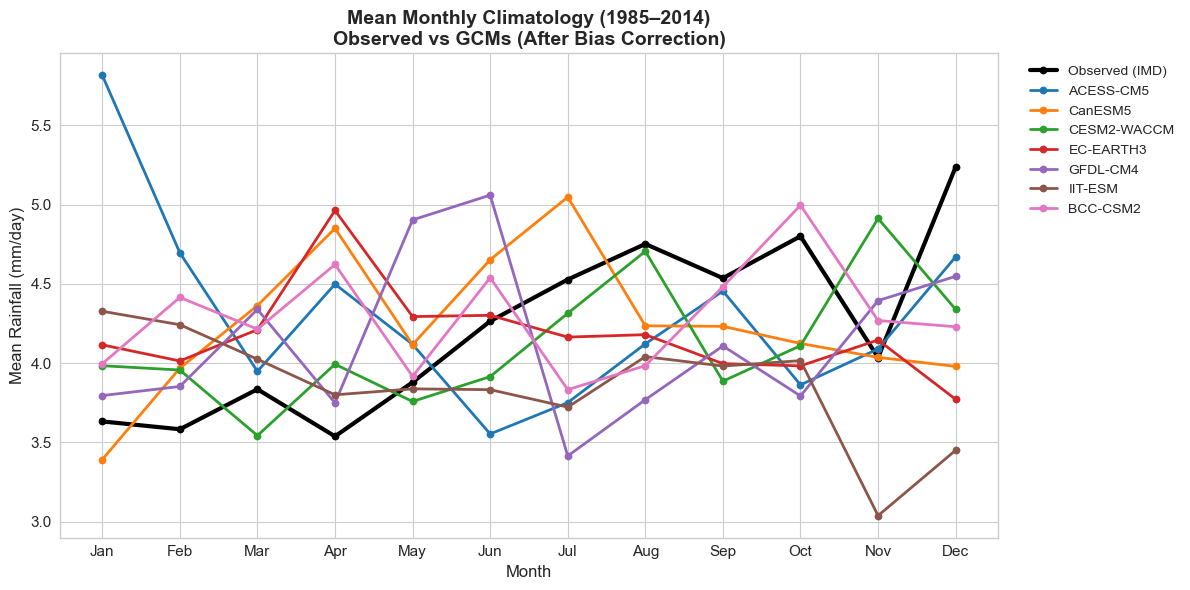

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# LOAD DATA
# ----------------------------
df = pd.read_csv("C:/Users/Windows/Desktop/ALL MODELs combined QM.csv")

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"])
df["Month"] = df["Date"].dt.month

# Observed monthly climatology
obs_month = df.groupby("Month")["IMD-Observerd"].mean()

# Identify AFTER bias-correction models
before_cols = [c for c in df.columns if "before" in c.lower()]
model_cols = [c for c in df.columns 
              if c not in before_cols 
              and c not in ["Date","Month","IMD-Observerd"]]

# Compute monthly climatology for each model
model_clim = {}
for col in model_cols:
    model_clim[col] = df.groupby("Month")[col].mean()

# ----------------------------
# PLOTTING
# ----------------------------
plt.style.use("seaborn-v0_8-whitegrid")

plt.figure(figsize=(12,6))

months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

# Plot Observed
plt.plot(months, obs_month.values, 
         color="black", linewidth=3, marker="o", 
         label="Observed (IMD)")

# Color palette for models
colors = plt.get_cmap("tab10")

# Plot all models
for i, (name, series) in enumerate(model_clim.items()):
    plt.plot(months, series.values, 
             linewidth=2, marker="o",
             color=colors(i),
             label=name)

plt.xlabel("Month", fontsize=12)
plt.ylabel("Mean Rainfall (mm/day)", fontsize=12)
plt.title("Mean Monthly Climatology (1985–2014)\nObserved vs GCMs (After Bias Correction)",
          fontsize=14, fontweight="bold")

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=10)
plt.tight_layout()
plt.show()


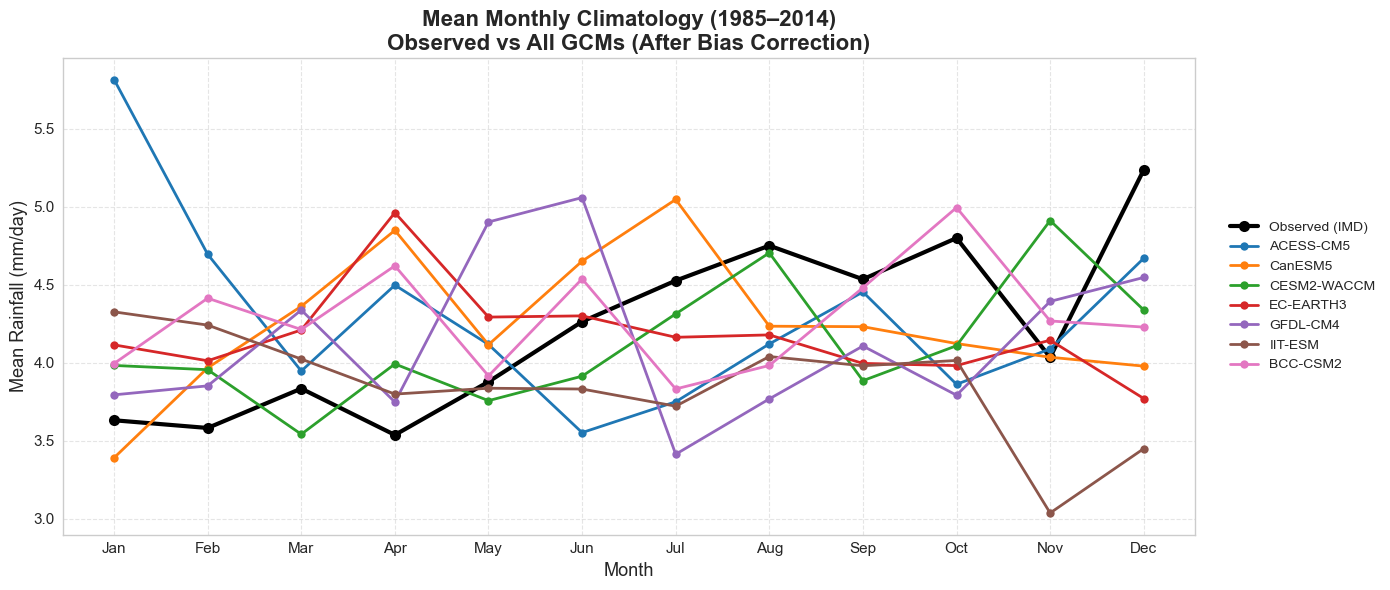

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------
# LOAD DATA
# -------------------------------------
df = pd.read_csv("C:/Users/Windows/Desktop/ALL MODELs combined QM.csv")
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"])
df["Month"] = df["Date"].dt.month

# Compute Observed monthly climatology
obs_month = df.groupby("Month")["IMD-Observerd"].mean().values

# Identify AFTER bias-correction model columns
before_cols = [c for c in df.columns if "before" in c.lower()]
excluded = ["Date","Month","IMD-Observerd"]
model_cols = [c for c in df.columns if c not in before_cols and c not in excluded]

# Compute monthly climatology for each model
model_clim = {}
for col in model_cols:
    model_clim[col] = df.groupby("Month")[col].mean().values

# -------------------------------------
# PLOTTING
# -------------------------------------
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(14,6))

months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

# Plot IMD Observed (bold black)
plt.plot(months, obs_month, marker="o", markersize=8, linewidth=3,
         color="black", label="Observed (IMD)")

# Color palette
colors = plt.get_cmap("tab10")

# Plot ALL models
for i, col in enumerate(model_cols):
    plt.plot(months, model_clim[col], 
             marker="o", markersize=6, linewidth=2,
             color=colors(i), label=col)

# -------------------------------------
# AESTHETICS
# -------------------------------------
plt.title("Mean Monthly Climatology (1985–2014)\nObserved vs All GCMs (After Bias Correction)",
          fontsize=16, fontweight="bold")

plt.xlabel("Month", fontsize=13)
plt.ylabel("Mean Rainfall (mm/day)", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)

# Legend outside plot (clean)
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=10)

plt.tight_layout()
plt.show()


Observed column: IMD-Observerd
Model columns found: ['ACESS-CM5', 'CanESM5', 'CESM2-WACCM', 'EC-EARTH3', 'GFDL-CM4', 'IIT-ESM', 'BCC-CSM2']
Observed monthly (Jan..Dec): [ 2.671  4.297  4.095  2.52   2.279  4.304 10.488 11.281  5.386  1.145
  0.762  1.604]


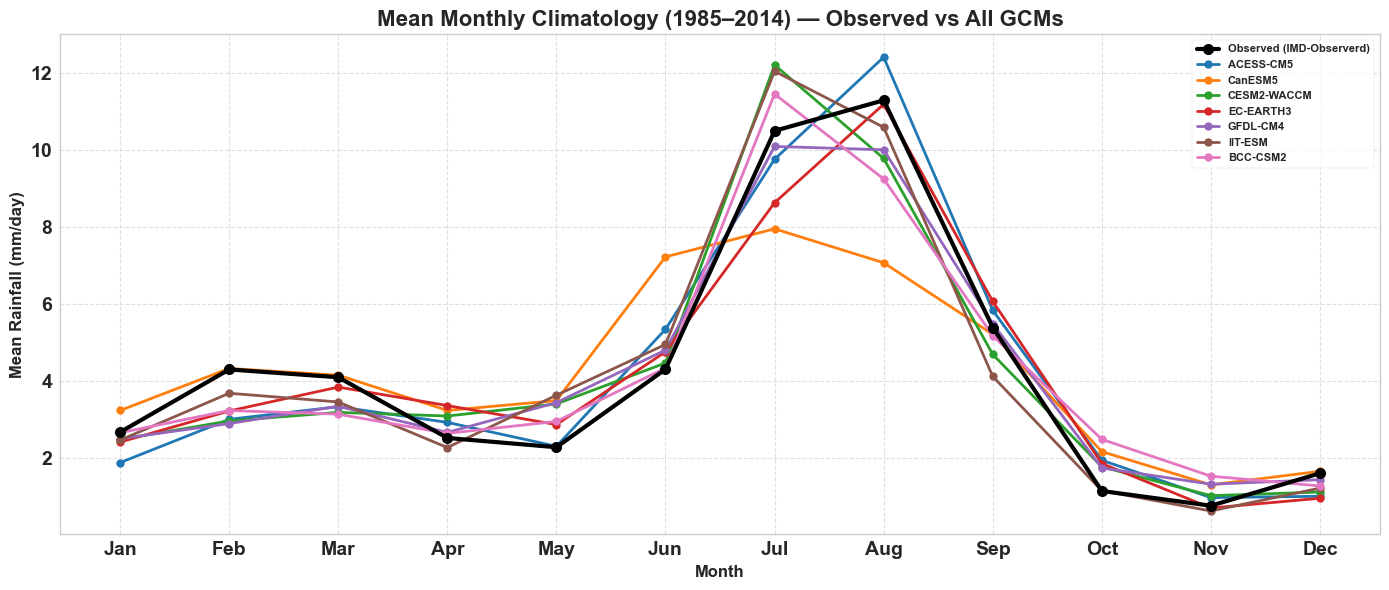

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- CONFIG ----
CSV_PATH = r"C:/Users/Windows/Desktop/ALL MODELs combined QM.csv"
DAYFIRST = True   # set False if your dates are mm/dd/yyyy
plt.style.use("seaborn-v0_8-whitegrid")
# -----------------

# Load
df = pd.read_csv(CSV_PATH)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=DAYFIRST, errors='coerce')
df = df.dropna(subset=['Date']).copy()
df['Month'] = df['Date'].dt.month

# Find observed column robustly
obs_col = next((c for c in df.columns if "imd" in c.lower() or "observe" in c.lower() or "obs" in c.lower()), None)
if obs_col is None:
    raise ValueError("Observed column not found. Check CSV column names.")
print("Observed column:", obs_col)

# Identify model columns (exclude 'before' variants and Date/Month/observed)
before_cols = [c for c in df.columns if "before" in c.lower()]
excluded = set(['Date', 'Month', obs_col])
model_cols = [c for c in df.columns if c not in before_cols and c not in excluded]

print("Model columns found:", model_cols)

# Compute monthly climatologies (reindex to ensure months 1..12)
months_idx = range(1,13)
obs_month = df.groupby('Month')[obs_col].mean().reindex(months_idx).values
print("Observed monthly (Jan..Dec):", np.round(obs_month,3))

model_clim = {}
for col in model_cols:
    model_clim[col] = df.groupby('Month')[col].mean().reindex(months_idx).values
    # optional debug print per model:
    # print(col, np.round(model_clim[col],3))

# ---- PLOT ----
months_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
plt.figure(figsize=(14,6))

# Observed bold
plt.plot(months_labels, obs_month, marker='o', markersize=8, linewidth=3,
         color='black', label=f'Observed ({obs_col})', zorder=5)

# Colors
cmap = plt.get_cmap('tab10')
for i, col in enumerate(model_cols):
    arr = model_clim[col]
    plt.plot(months_labels, arr, marker='o', markersize=6, linewidth=2,
             color=cmap(i % 10), label=col, zorder=3)

plt.title("Mean Monthly Climatology (1985–2014) — Observed vs All GCMs",
          fontsize=16, fontweight='bold')

plt.ylabel("Mean Rainfall (mm/day)", fontsize=12, fontweight='bold')
plt.xlabel("Month", fontsize=12, fontweight='bold')

# ---- Make month names bold ----
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.6)

# Legend inside the plot
plt.legend(
    loc='upper right',
    fontsize=10,
    prop={'weight': 'bold'},   # <-- bold legend text
    frameon=True
)
plt.savefig("C:/Users/Windows/Desktop/Climate Figures/monthly_climatology.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

